In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.Exploratory Data Analysis (raw series)

In [ ]:
data=pd.read_csv(r"/content/bitcoin_2010-07-17_2024-05-23 (1).csv")
btc=pd.DataFrame(data)
btc['Start']=pd.to_datetime(btc['Start'])
btc['End']=pd.to_datetime(btc['End'])
btc=btc.set_index('Start')
btc=btc.sort_index(ascending=True)
df=btc.loc['2014-01-20':]
df

,End,Open,High,Low,Close,Volume,Market Cap
Start,,,,,,,
2014-01-20,2014-01-21,871.39,886.39,853.87,870.20,3.167142e+07,1.072904e+10
2014-01-21,2014-01-22,869.65,881.20,855.93,863.91,2.115327e+07,1.064088e+10
2014-01-22,2014-01-23,867.21,870.15,837.36,845.59,1.739519e+07,1.052334e+10
2014-01-23,2014-01-24,845.46,851.57,819.32,822.04,1.700802e+07,1.030080e+10
2014-01-24,2014-01-25,822.43,822.43,783.58,797.07,3.019734e+07,9.881758e+09
...,...,...,...,...,...,...,...
2024-05-18,2024-05-19,66939.82,67376.41,66640.01,66914.58,9.377570e+10,1.318743e+12
2024-05-19,2024-05-20,66972.63,67598.31,66005.33,66347.05,8.441685e+10,1.317072e+12
2024-05-20,2024-05-21,66222.45,71456.55,66139.62,71418.17,9.769064e+10,1.332128e+12


DATA CLEANING

In [ ]:
def clean_data(data):
    df_clean = data.copy()
    df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_clean.ffill(inplace=True)
    df_clean.dropna(inplace=True)

    return df_clean

df = clean_data(df)
df

,End,Open,High,Low,Close,Volume,Market Cap
Start,,,,,,,
2014-01-20,2014-01-21,871.39,886.39,853.87,870.20,3.167142e+07,1.072904e+10
2014-01-21,2014-01-22,869.65,881.20,855.93,863.91,2.115327e+07,1.064088e+10
2014-01-22,2014-01-23,867.21,870.15,837.36,845.59,1.739519e+07,1.052334e+10
2014-01-23,2014-01-24,845.46,851.57,819.32,822.04,1.700802e+07,1.030080e+10
2014-01-24,2014-01-25,822.43,822.43,783.58,797.07,3.019734e+07,9.881758e+09
...,...,...,...,...,...,...,...
2024-05-18,2024-05-19,66939.82,67376.41,66640.01,66914.58,9.377570e+10,1.318743e+12
2024-05-19,2024-05-20,66972.63,67598.31,66005.33,66347.05,8.441685e+10,1.317072e+12
2024-05-20,2024-05-21,66222.45,71456.55,66139.62,71418.17,9.769064e+10,1.332128e+12


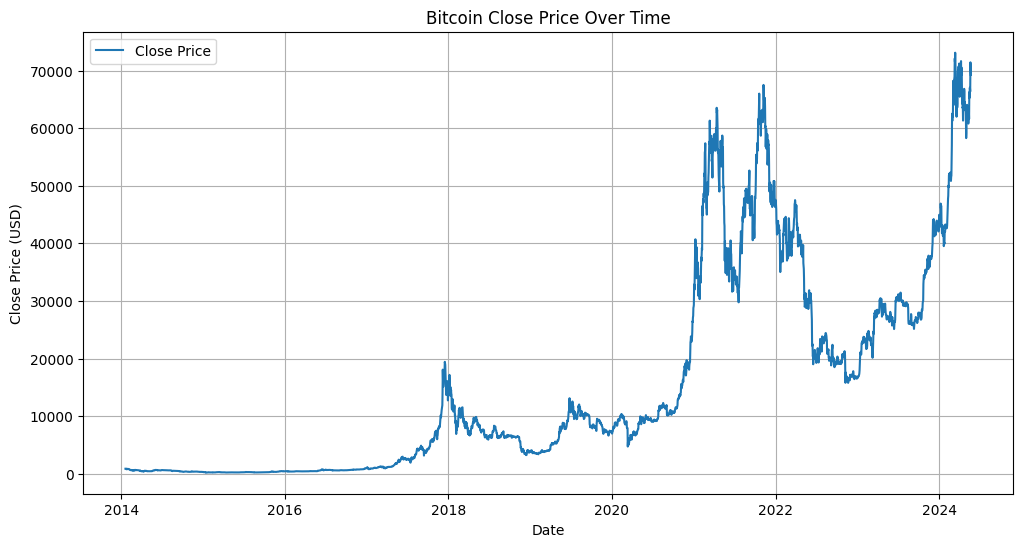

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title('Bitcoin Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True)
plt.legend()
plt.show()

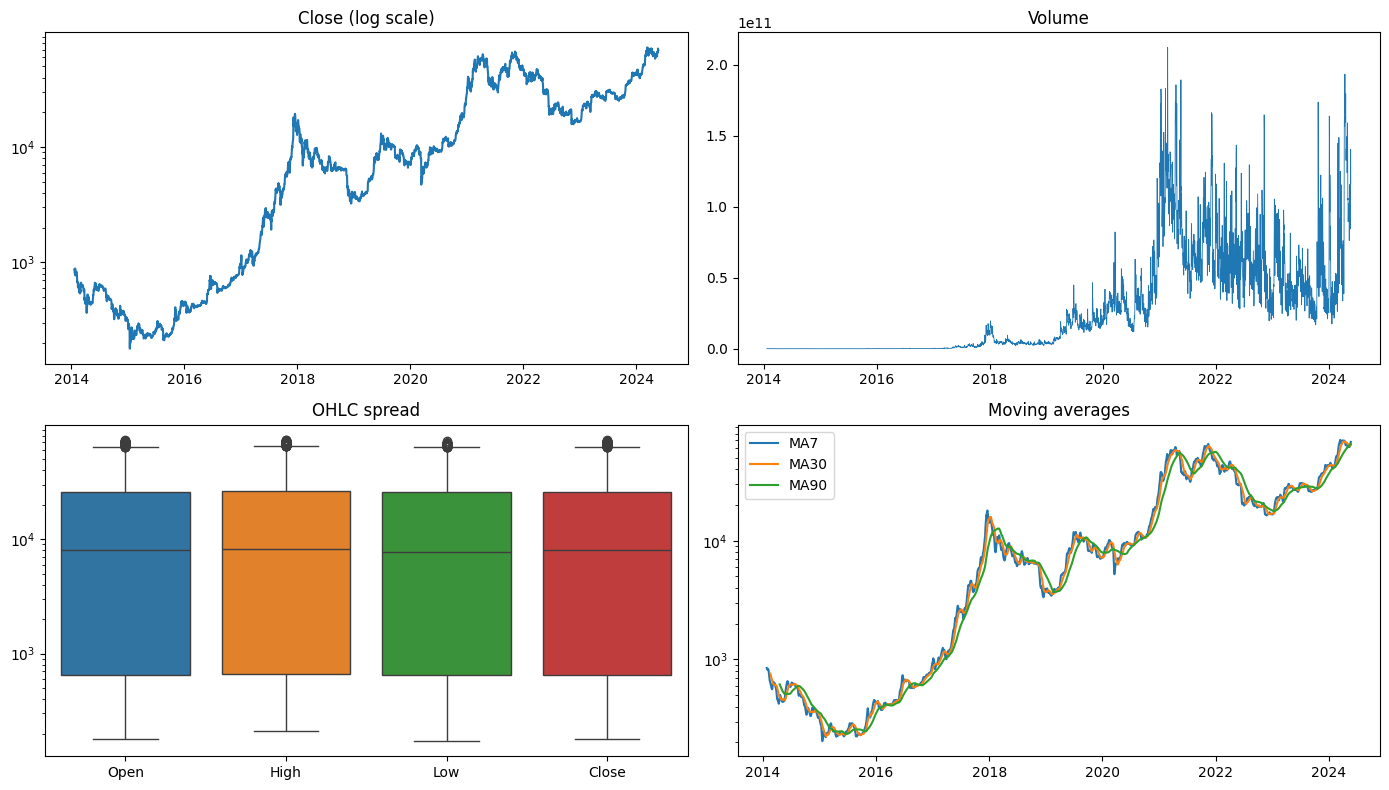

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0,0].plot(df.index, df['Close']); ax[0,0].set_yscale('log'); ax[0,0].set_title('Close (log scale)')
ax[0,1].plot(df.index, df['Volume'], lw=.6); ax[0,1].set_title('Volume')
sns.boxplot(data=df[['Open','High','Low','Close']], ax=ax[1,0]); ax[1,0].set_yscale('log'); ax[1,0].set_title('OHLC spread')
ax[1,1].plot(df['Close'].rolling(7).mean(),  label='MA7')
ax[1,1].plot(df['Close'].rolling(30).mean(), label='MA30')
ax[1,1].plot(df['Close'].rolling(90).mean(), label='MA90')
ax[1,1].set_yscale('log'); ax[1,1].legend(); ax[1,1].set_title('Moving averages')
plt.tight_layout(); plt.show()

2. Feature Creation

In [ ]:
df = df.sort_index()
c_price = df['Close']

for col in ['Open', 'High', 'Low', 'Close']:
    df[f'{col}_Lag1'] = df[col].shift(1)

df['LogReturn'] = np.log(c_price / c_price.shift(1))
df['target']    = df['LogReturn'].shift(-1)

for lag in range(1, 8):
    df[f'Lag{lag}'] = df['LogReturn'].shift(lag)

df['AutoCorr_5'] = (
    df['LogReturn']
    .rolling(5)
    .apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)
)

for w in [7, 14, 20, 50, 100, 200]:
    df[f'SMA_{w}'] = c_price.rolling(w).mean()
    df[f'EMA_{w}'] = c_price.ewm(span=w, adjust=False).mean()

df['SMA_Ratio_14']  = c_price / df['SMA_14']
df['SMA_Ratio_50']  = c_price / df['SMA_50']
df['SMA_Ratio_200'] = c_price / df['SMA_200']

df['GoldenCross'] = (df['SMA_50'] > df['SMA_200']).astype(int)
df['SMA50_200_Diff'] = df['SMA_50'] - df['SMA_200']

df['SMA_14_Lag1'] = df['SMA_14'].shift(1)
df['EMA_14_Lag1'] = df['EMA_14'].shift(1)

def compute_rsi(prices, n=14):
    deltas   = prices.diff()
    gain     = deltas.where(deltas > 0, 0.0)
    loss     = -deltas.where(deltas < 0, 0.0)
    avg_gain = gain.rolling(n).mean()
    avg_loss = loss.rolling(n).mean()
    rs       = avg_gain / avg_loss
    return 100 - 100 / (1 + rs)

df['RSI_14']        = compute_rsi(c_price, 14)
df['RSI_7']         = compute_rsi(c_price, 7)
df['RSI_21']        = compute_rsi(c_price, 21)
df['RSI_Change']    = df['RSI_14'].diff()
df['RSI_14_Lag1']   = df['RSI_14'].shift(1)

df['RSI_Overbought'] = (df['RSI_14'] > 70).astype(int)
df['RSI_Oversold']   = (df['RSI_14'] < 30).astype(int)

period, mult = 20, 2
df['MB']      = c_price.rolling(period).mean()
df['StdDev']  = c_price.rolling(period).std()
df['UB']      = df['MB'] + mult * df['StdDev']
df['LB']      = df['MB'] - mult * df['StdDev']

df['BB_Bandwidth']  = (df['UB'] - df['LB']) / df['MB']
df['BB_PercentB']   = (c_price - df['LB']) / (df['UB'] - df['LB'])
df['BB_Squeeze']    = (df['BB_Bandwidth'] < df['BB_Bandwidth'].rolling(50).quantile(0.2)).astype(int)

df['BB_Bandwidth_Lag1'] = df['BB_Bandwidth'].shift(1)
df['BB_PercentB_Lag1']  = df['BB_PercentB'].shift(1)
df['MB_Lag1']           = df['MB'].shift(1)

df.drop(columns=['StdDev'], inplace=True)

ema12 = c_price.ewm(span=12, adjust=False).mean()
ema26 = c_price.ewm(span=26, adjust=False).mean()
df['MACD']        = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']
df['MACD_Cross']  = (df['MACD'] > df['MACD_Signal']).astype(int)

def compute_atr(high, low, close, n=14):
    hl  = high - low
    hpc = (high - close.shift(1)).abs()
    lpc = (low  - close.shift(1)).abs()
    tr  = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
    return tr.rolling(n).mean()

df['ATR_14'] = compute_atr(df['High'], df['Low'], c_price, 14)
df['ATR_7']  = compute_atr(df['High'], df['Low'], c_price, 7)
df['ATR_Ratio'] = df['ATR_14'] / c_price

def stochastic(high, low, close, k=14, d=3):
    low_min  = low.rolling(k).min()
    high_max = high.rolling(k).max()
    pct_k    = 100 * (close - low_min) / (high_max - low_min)
    pct_d    = pct_k.rolling(d).mean()
    return pct_k, pct_d

df['Stoch_K'], df['Stoch_D'] = stochastic(df['High'], df['Low'], c_price)
df['Stoch_Cross'] = (df['Stoch_K'] > df['Stoch_D']).astype(int)

obv = [0]
for i in range(1, len(df)):
    if df['Close'].iloc[i] > df['Close'].iloc[i-1]:
        obv.append(obv[-1] + df['Volume'].iloc[i])
    elif df['Close'].iloc[i] < df['Close'].iloc[i-1]:
        obv.append(obv[-1] - df['Volume'].iloc[i])
    else:
        obv.append(obv[-1])
df['OBV']        = obv
df['OBV_EMA']    = pd.Series(obv, index=df.index).ewm(span=14).mean()
df['OBV_Signal'] = (df['OBV'] > df['OBV_EMA']).astype(int)

df['Volume_Log']       = np.log(df['Volume'])
df['Volume_SMA_14']    = df['Volume'].rolling(14).mean()
df['Volume_Ratio']     = df['Volume'] / df['Volume_SMA_14']
df['Volume_Lag1']      = df['Volume'].shift(1)

df['MarketCap_Log']    = np.log(df['Market Cap'])
df['MarketCap_Return'] = np.log(df['Market Cap'] / df['Market Cap'].shift(1))

df['HL_Spread']      = df['High'] - df['Low']
df['OC_Spread']      = df['Close'] - df['Open']
df['Upper_Shadow']   = df['High'] - df[['Open','Close']].max(axis=1)
df['Lower_Shadow']   = df[['Open','Close']].min(axis=1) - df['Low']
df['Body_Ratio']     = df['OC_Spread'].abs() / df['HL_Spread'].replace(0, np.nan)
df['HL_Spread_Log']  = np.log(df['HL_Spread'].replace(0, np.nan))

for w in [7, 14, 30]:
    df[f'Volatility_{w}d']  = df['LogReturn'].rolling(w).std() * np.sqrt(252)
    df[f'Momentum_{w}d']    = c_price / c_price.shift(w) - 1
    df[f'MaxDD_{w}d']       = (
        c_price.rolling(w).max() - c_price
    ) / c_price.rolling(w).max()

df['52w_High']          = c_price.rolling(252).max()
df['52w_Low']           = c_price.rolling(252).min()
df['Dist_52w_High']     = (c_price - df['52w_High']) / df['52w_High']
df['Dist_52w_Low']      = (c_price - df['52w_Low'])  / df['52w_Low']

df['DayOfYear']         = pd.DatetimeIndex(df.index).dayofyear
df['Year']              = pd.DatetimeIndex(df.index).year
HALVING_DATES = pd.to_datetime(['2012-11-28','2016-07-09','2020-05-11','2024-04-19'])
def days_since_halving(date):
    past = HALVING_DATES[HALVING_DATES <= date]
    return (date - past[-1]).days if len(past) else np.nan
df['Days_Since_Halving'] = pd.DatetimeIndex(df.index).map(days_since_halving)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. End
2. Open
3. High
4. Low
5. Close
6. Volume
7. Market Cap
8. Open_Lag1
9. High_Lag1
10. Low_Lag1
11. Close_Lag1
12. LogReturn
13. target
14. Lag1
15. Lag2
16. Lag3
17. Lag4
18. Lag5
19. Lag6
20. Lag7
21. AutoCorr_5
22. SMA_7
23. EMA_7
24. SMA_14
25. EMA_14
26. SMA_20
27. EMA_20
28. SMA_50
29. EMA_50
30. SMA_100
31. EMA_100
32. SMA_200
33. EMA_200
34. SMA_Ratio_14
35. SMA_Ratio_50
36. SMA_Ratio_200
37. GoldenCross
38. SMA50_200_Diff
39. SMA_14_Lag1
40. EMA_14_Lag1
41. RSI_14
42. RSI_7
43. RSI_21
44. RSI_Change
45. RSI_14_Lag1
46. RSI_Overbought
47. RSI_Oversold
48. MB
49. UB
50. LB
51. BB_Bandwidth
52. BB_PercentB
53. BB_Squeeze
54. BB_Bandwidth_Lag1
55. BB_PercentB_Lag1
56. MB_Lag1
57. MACD
58. MACD_Signal
59. MACD_Hist
60. MACD_Cross
61. ATR_14
62. ATR_7
63. ATR_Ratio
64. Stoch_K
65. Stoch_D
66. Stoch_Cross
67. OBV
68. OBV_EMA
69. OBV_Signal
70. Volume_Log
71. Volume_SMA_14
72. Volume_Ratio
73. Volume_Lag1
74. MarketCap_Log
75. MarketCap_Return
76. HL_Spread
77. OC_Spread
78. Upp

Statistical feature extraction

In [ ]:
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
import warnings

warnings.filterwarnings('ignore')

TARGET              = 'target'
CORR_THRESHOLD      = 0.90
STAT_SIG            = 0.05
MI_TOP_N            = 40
VIF_THRESHOLD       = 10.0
DROP_NONSTATIONARY  = False
PRICE_LIKE_COLS     = []
RANDOM_SEED         = 42

def _correlation_filter(df, features, target):
    corr_matrix      = df[features].corr(method='pearson')
    corr_with_target = df[features].corrwith(df[target]).abs()

    redundant_pairs, to_drop = [], set()
    for feat_a, feat_b in combinations(features, 2):
        c = abs(corr_matrix.loc[feat_a, feat_b])
        if c >= CORR_THRESHOLD:
            redundant_pairs.append((feat_a, feat_b, round(c, 4)))
            if corr_with_target.get(feat_a, 0) >= corr_with_target.get(feat_b, 0):
                to_drop.add(feat_b)
            else:
                to_drop.add(feat_a)

    survivors = [f for f in features if f not in to_drop]
    return survivors, corr_with_target, redundant_pairs, to_drop

def _cointegration_check(df, price_cols):
    if not price_cols or len(price_cols) < 2:
        return pd.DataFrame()
    try:
        from statsmodels.tsa.stattools import coint
    except ImportError:
        return pd.DataFrame()

    results = []
    for a, b in combinations(price_cols, 2):
        s_a, s_b = df[a].dropna(), df[b].dropna()
        common   = s_a.index.intersection(s_b.index)
        if len(common) < 50:
            continue
        try:
            _, p, _ = coint(s_a[common], s_b[common])
            results.append({'col_a': a, 'col_b': b,
                            'p_value': round(p, 4),
                            'cointegrated': p < STAT_SIG})
        except Exception:
            pass

    return pd.DataFrame(results).sort_values('p_value') if results else pd.DataFrame()

def _stationarity_check(df, features):
    try:
        from statsmodels.tsa.stattools import adfuller
    except ImportError:
        return pd.DataFrame()

    rows = []
    for col in features:
        series = df[col].dropna()
        if len(series) < 30:
            continue
        try:
            result = adfuller(series, autolag='AIC')
            rows.append({'feature':       col,
                         'adf_stat':      round(result[0], 4),
                         'p_value':       round(result[1], 4),
                         'is_stationary': result[1] < STAT_SIG})
        except Exception:
            pass

    return pd.DataFrame(rows).sort_values('p_value') if rows else pd.DataFrame()

def _mutual_info_filter(df, features, target):
    X    = df[features].copy()
    y    = df[target].copy()
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]

    X_sc      = StandardScaler().fit_transform(X)
    mi_scores = mutual_info_regression(X_sc, y, random_state=RANDOM_SEED)
    mi_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)

    survivors = mi_series.head(MI_TOP_N).index.tolist()
    return survivors, mi_series

def _vif_filter(df, features):
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    remaining = list(features)
    while True:
        X        = df[remaining].dropna()
        vif_data = pd.DataFrame({
            'feature': remaining,
            'VIF':     [variance_inflation_factor(X.values, i)
                        for i in range(len(remaining))]
        }).sort_values('VIF', ascending=False)

        max_vif = vif_data['VIF'].iloc[0]
        if max_vif <= VIF_THRESHOLD:
            break
        drop_feat = vif_data['feature'].iloc[0]
        remaining.remove(drop_feat)

    return remaining, vif_data

features = [c for c in df.columns if c != TARGET]

if 'End' in features:
    features.remove('End')

low_var  = [f for f in features if df[f].std() < 1e-6]
features = [f for f in features if f not in low_var]

features, corr_with_target, redundant_pairs, dropped_corr = \
    _correlation_filter(df, features, TARGET)

price_cols_present = [c for c in PRICE_LIKE_COLS if c in features]
coint_df = _cointegration_check(df, price_cols_present)

stat_df = _stationarity_check(df, features)
if not stat_df.empty:
    if DROP_NONSTATIONARY:
        ns = stat_df.loc[~stat_df['is_stationary'], 'feature'].tolist()
        features = [f for f in features if f not in ns]

features, mi_scores = _mutual_info_filter(df, features, TARGET)

features, vif_df = _vif_filter(df[features + [TARGET]].dropna(), features)

for i, f in enumerate(features, 1):
    mi = mi_scores[f] if f in mi_scores.index else 0
    print(f"  {i:>2}. {f:<40} MI={mi:.4f}")

surviving_features = features

   1. Volatility_7d                            MI=0.0601
   2. 52w_High                                 MI=0.0588
   3. Days_Since_Halving                       MI=0.0535
   4. Momentum_7d                              MI=0.0467
   5. Dist_52w_Low                             MI=0.0345
   6. MarketCap_Return                         MI=0.0334
   7. Lag3                                     MI=0.0315
   8. Lag6                                     MI=0.0274
   9. SMA50_200_Diff                           MI=0.0274
  10. Lag5                                     MI=0.0272
  11. MACD                                     MI=0.0270
  12. MACD_Hist                                MI=0.0260
  13. Momentum_14d                             MI=0.0246
  14. HL_Spread                                MI=0.0240
  15. Lag1                                     MI=0.0218
  16. OC_Spread                                MI=0.0209
  17. LogReturn                                MI=0.0207
  18. Volume                   

Voting System based Feature selection

In [ ]:
from collections import Counter
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV, RidgeCV
import warnings
warnings.filterwarnings('ignore')

TARGET      = 'target'
TOP_N_EACH  = 20
VOTE_THRESH = 3
RANDOM_SEED = 42

df_sub    = df[surviving_features + [TARGET]].dropna()
split_idx = int(len(df_sub) * 0.80)

X_train = df_sub.iloc[:split_idx][surviving_features]
y_train = df_sub.iloc[:split_idx][TARGET]
X_test  = df_sub.iloc[split_idx:][surviving_features]
y_test  = df_sub.iloc[split_idx:][TARGET]

scaler  = StandardScaler()
X_tr_sc = pd.DataFrame(scaler.fit_transform(X_train),
                        columns=surviving_features, index=X_train.index)
X_te_sc = pd.DataFrame(scaler.transform(X_test),
                        columns=surviving_features, index=X_test.index)


print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Candidate features : {len(surviving_features)}\n")


def top_n(series, n=TOP_N_EACH):
    return series.abs().nlargest(n).index.tolist()

all_scores, all_top_n = {}, {}

rf = RandomForestRegressor(n_estimators=300, max_depth=6,
                           min_samples_leaf=5, random_state=RANDOM_SEED,
                           n_jobs=-1).fit(X_train, y_train)
s = pd.Series(rf.feature_importances_, index=surviving_features)
all_scores['RandomForest'] = s
all_top_n['RandomForest']  = top_n(s)

pi = permutation_importance(rf, X_test, y_test,
                             n_repeats=15, random_state=RANDOM_SEED, n_jobs=-1)
s = pd.Series(pi.importances_mean, index=surviving_features)
all_scores['RF_Permutation'] = s
all_top_n['RF_Permutation']  = top_n(s)

gbm = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                 learning_rate=0.05, subsample=0.8,
                                 random_state=RANDOM_SEED).fit(X_train, y_train)
s = pd.Series(gbm.feature_importances_, index=surviving_features)
all_scores['GBM'] = s
all_top_n['GBM']  = top_n(s)

lasso = LassoCV(cv=5, max_iter=10000, random_state=RANDOM_SEED).fit(X_tr_sc, y_train)
s = pd.Series(np.abs(lasso.coef_), index=surviving_features)
all_scores['Lasso'] = s
all_top_n['Lasso']  = top_n(s)

ridge = RidgeCV(cv=5).fit(X_tr_sc, y_train)
s = pd.Series(np.abs(ridge.coef_), index=surviving_features)
all_scores['Ridge'] = s
all_top_n['Ridge']  = top_n(s)

mi = mutual_info_regression(X_train, y_train, random_state=RANDOM_SEED)
s  = pd.Series(mi, index=surviving_features)
all_scores['MutualInfo'] = s
all_top_n['MutualInfo']  = top_n(s)


model_names  = list(all_scores.keys())
vote_counter = Counter()
for top_list in all_top_n.values():
    for feat in top_list:
        vote_counter[feat] += 1

vote_df = pd.DataFrame(vote_counter.most_common(), columns=['feature', 'votes'])
for m in model_names:
    ranked = all_scores[m].rank(pct=True)
    vote_df[m] = vote_df['feature'].map(ranked)

vote_df['avg_rank_score'] = vote_df[model_names].mean(axis=1)
vote_df = (vote_df
           .sort_values(['votes', 'avg_rank_score'], ascending=[False, False])
           .reset_index(drop=True))
vote_df.index += 1


print(f"CONSENSUS VOTE TABLE  (top-{TOP_N_EACH} per model, {len(model_names)} models)")
print(vote_df[['feature', 'votes', 'avg_rank_score']].to_string())
print()


final_features = vote_df[vote_df['votes'] >= VOTE_THRESH]['feature'].tolist()

print(f"FINAL FEATURES  (voted by >= {VOTE_THRESH}/{len(model_names)} models)")
for i, f in enumerate(final_features, 1):
    row = vote_df[vote_df['feature'] == f].iloc[0]
    print(f"  {i:>2}. {f:<40}  votes={int(row['votes'])}  "
          f"avg_rank={row['avg_rank_score']:.3f}")
print(f"\nTotal final features : {len(final_features)}")

df_final = df[final_features + [TARGET]].dropna()
split2   = int(len(df_final) * 0.80)

X_final_train = df_final.iloc[:split2][final_features]
y_final_train = df_final.iloc[:split2][TARGET]
X_final_test  = df_final.iloc[split2:][final_features]
y_final_test  = df_final.iloc[split2:][TARGET]

sc2 = StandardScaler()
X_final_tr_sc = pd.DataFrame(sc2.fit_transform(X_final_train),
                               columns=final_features, index=X_final_train.index)
X_final_te_sc = pd.DataFrame(sc2.transform(X_final_test),
                               columns=final_features, index=X_final_test.index)

print(f"\nFinal train set : {X_final_train.shape}")
print(f"Final test set  : {X_final_test.shape}")





Train : (2818, 29)  |  Test : (705, 29)
Candidate features : 29

CONSENSUS VOTE TABLE  (top-20 per model, 6 models)
               feature  votes  avg_rank_score
1            LogReturn      6        0.879310
2         Momentum_14d      6        0.747126
3          Momentum_7d      6        0.704023
4   Days_Since_Halving      6        0.637931
5                 Lag6      6        0.603448
6                 Lag7      5        0.626437
7                 Lag5      5        0.626437
8            MaxDD_30d      5        0.589080
9                 Lag1      5        0.586207
10    MarketCap_Return      5        0.583333
11       Dist_52w_High      5        0.580460
12        Dist_52w_Low      5        0.531609
13          RSI_Change      5        0.500000
14          Body_Ratio      5        0.497126
15      SMA50_200_Diff      5        0.454023
16                Lag3      5        0.442529
17           DayOfYear      5        0.367816
18        Volume_Ratio      4        0.413793
19        

Screening evidence

In [ ]:
from sklearn.ensemble import RandomForestRegressor
corr_t = df_final.corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)

print('|corr| of FINAL features vs next-day return:')
print(corr_t.round(3).to_string())

rf_eval = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_eval.fit(X_final_train, y_final_train)

imp = pd.Series(rf_eval.feature_importances_, index=final_features).sort_values(ascending=False)

print('\nRandomForest importance (train only):')
print(imp.round(3).to_string())

|corr| of FINAL features vs next-day return:
Dist_52w_High         0.042
Lag5                  0.041
52w_High              0.031
LogReturn             0.027
Lag7                  0.024
Body_Ratio            0.024
Momentum_14d          0.023
OC_Spread             0.023
Volume_Ratio          0.022
Momentum_7d           0.020
Lag6                  0.019
Days_Since_Halving    0.018
Lag2                  0.018
Lower_Shadow          0.014
Lag3                  0.013
DayOfYear             0.012
MaxDD_30d             0.012
Dist_52w_Low          0.010
Lag1                  0.007
MACD_Hist             0.006
RSI_Change            0.005
MarketCap_Return      0.004
SMA50_200_Diff        0.001

RandomForest importance (train only):
Dist_52w_Low          0.060
Momentum_14d          0.057
Lag3                  0.055
Days_Since_Halving    0.055
Momentum_7d           0.053
Lag7                  0.050
LogReturn             0.050
Body_Ratio            0.049
Lag6                  0.049
MaxDD_30d           

3a. Return magnitude (regression) — expected near-zero

In [ ]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

print("NEXT-DAY LOG-RETURN MAGNITUDE REGRESSION (CORE SET)")
print(f'magnitude | train={len(y_final_train)} test={len(y_final_test)}\n')

lr_model = LinearRegression().fit(X_final_tr_sc, y_final_train)
print(" Linear Regression ")
evaluate_model('LinearReg', y_final_test, lr_model.predict(X_final_te_sc))
print()

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
).fit(X_final_tr_sc, y_final_train)
print(" Random Forest Regressor ")
evaluate_model('RandomForest', y_final_test, rf_model.predict(X_final_te_sc))
print()

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1
).fit(X_final_tr_sc, y_final_train)
print(" XGBoost Regressor ")
evaluate_model('XGBoost', y_final_test, xgb_model.predict(X_final_te_sc))
print()

print('(R2 <= 0 across models -> next-day magnitude is unpredictable, as the EDA predicted.)')

NEXT-DAY LOG-RETURN MAGNITUDE REGRESSION (CORE SET)
magnitude | train=2818 test=705

 Linear Regression 
Mean Absolute Error (MAE): 0.0183
Mean Squared Error (MSE): 0.0007
Root Mean Squared Error (RMSE): 0.0271
R-squared (R2): -0.0248
Directional Accuracy: 50.50%

 Random Forest Regressor 
Mean Absolute Error (MAE): 0.0227
Mean Squared Error (MSE): 0.0011
Root Mean Squared Error (RMSE): 0.0327
R-squared (R2): -0.4945
Directional Accuracy: 49.22%

 XGBoost Regressor 
Mean Absolute Error (MAE): 0.0213
Mean Squared Error (MSE): 0.0009
Root Mean Squared Error (RMSE): 0.0299
R-squared (R2): -0.2434
Directional Accuracy: 46.10%

(R2 <= 0 across models -> next-day magnitude is unpredictable, as the EDA predicted.)


3b. Next-day direction (classification) — the one positive result

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

XGB_PARAMS = dict(n_estimators=400, learning_rate=0.02, max_depth=4, subsample=0.8,
                  colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)

yc_tr = (y_final_train > 0).astype(int)
yc_te = (y_final_test > 0).astype(int)
Xc_tr = X_final_tr_sc
Xc_te = X_final_te_sc

clf      = XGBClassifier(**XGB_PARAMS).fit(Xc_tr, yc_tr)
p_dir    = clf.predict_proba(Xc_te)[:, 1]
pred_dir = (p_dir > 0.5).astype(int)

print(f'Base classifier   Acc={accuracy_score(yc_te,pred_dir):.3f}  ROC-AUC={roc_auc_score(yc_te,p_dir):.3f}  (test up-rate={yc_te.mean():.2f})')

Base classifier   Acc=0.495  ROC-AUC=0.502  (test up-rate=0.50)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_train_c = (y_final_train > 0).astype(int)
y_test_c = (y_final_test > 0).astype(int)

print(f'B) direction  | train={len(y_train_c)}  test={len(y_test_c)}  | up-rate train={y_train_c.mean():.2f} test={y_test_c.mean():.2f}')

clf = XGBClassifier(n_estimators=400, learning_rate=0.02, max_depth=4, subsample=0.8,
                    colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1).fit(X_final_tr_sc, y_train_c)
p = clf.predict_proba(X_final_te_sc)[:, 1]
pred = (p > 0.5).astype(int)
print(f'XGBClassifier   Acc={accuracy_score(y_test_c,pred):.3f}  F1={f1_score(y_test_c,pred):.3f}  ROC-AUC={roc_auc_score(y_test_c,p):.3f}')

try:
    from catboost import CatBoostClassifier
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'catboost'])
    from catboost import CatBoostClassifier

cb = CatBoostClassifier(iterations=400, learning_rate=0.02, depth=4, verbose=0, random_state=42).fit(X_final_tr_sc, y_train_c)
pc = cb.predict_proba(X_final_te_sc)[:, 1]
predc = (pc > 0.5).astype(int)
print(f'CatBoost        Acc={accuracy_score(y_test_c,predc):.3f}  F1={f1_score(y_test_c,predc):.3f}  ROC-AUC={roc_auc_score(y_test_c,pc):.3f}')
print('(ROC-AUC ~0.50 = no directional edge; >0.55 starts to be interesting)')

B) direction  | train=2818  test=705  | up-rate train=0.54 test=0.50
XGBClassifier   Acc=0.495  F1=0.529  ROC-AUC=0.502
CatBoost        Acc=0.499  F1=0.566  ROC-AUC=0.506
(ROC-AUC ~0.50 = no directional edge; >0.55 starts to be interesting)


3c. Forward 30-day volatility, and a 7-day return horizon

In [ ]:

df_vol = df_final.copy()
df_vol['target_C'] = df_vol['LogReturn'].rolling(30).std().shift(-30)
df_vol = df_vol.dropna(subset=['target_C'])

split_idx_vol = int(len(df_vol) * 0.80)

X_train_vol = df_vol.iloc[:split_idx_vol][final_features]
y_train_vol = df_vol.iloc[:split_idx_vol]['target_C']
X_test_vol = df_vol.iloc[split_idx_vol:][final_features]
y_test_vol = df_vol.iloc[split_idx_vol:]['target_C']

sc_vol = StandardScaler()
X_tr_sc_vol = pd.DataFrame(sc_vol.fit_transform(X_train_vol), columns=final_features, index=X_train_vol.index)
X_te_sc_vol = pd.DataFrame(sc_vol.transform(X_test_vol), columns=final_features, index=X_test_vol.index)

print(f'C) future 30d volatility  | train={len(y_train_vol)}  test={len(y_test_vol)}')

xgb_vol = XGBRegressor(n_estimators=400, learning_rate=0.02, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8, random_state=42,
                       n_jobs=-1).fit(X_tr_sc_vol, y_train_vol)
evaluate_model('XGB', y_test_vol, xgb_vol.predict(X_te_sc_vol))

rf_vol = RandomForestRegressor(n_estimators=300, random_state=42,
                               n_jobs=-1).fit(X_tr_sc_vol, y_train_vol)
evaluate_model('RandomForest', y_test_vol, rf_vol.predict(X_te_sc_vol))

print('(Expect the strongest R2 here — volatility persists, unlike returns.)')

C) future 30d volatility  | train=2794  test=699
Mean Absolute Error (MAE): 0.0179
Mean Squared Error (MSE): 0.0005
Root Mean Squared Error (RMSE): 0.0233
R-squared (R2): -6.0973
Directional Accuracy: 100.00%
Mean Absolute Error (MAE): 0.0184
Mean Squared Error (MSE): 0.0008
Root Mean Squared Error (RMSE): 0.0281
R-squared (R2): -9.3044
Directional Accuracy: 100.00%
(Expect the strongest R2 here — volatility persists, unlike returns.)


In [ ]:


corr_t = df_final.corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('|corr| of CORE features vs next-day return:')
print(corr_t.round(3).to_string())

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_final_train, y_final_train)
imp = pd.Series(rf.feature_importances_, index=final_features).sort_values(ascending=False)
print('\nRandomForest importance (train only):')
print(imp.round(3).to_string())
print('\n(No feature exceeds ~0.07 |corr|; importances are near-uniform -> signal is weak and aggregate.)')

|corr| of CORE features vs next-day return:
Dist_52w_High         0.042
Lag5                  0.041
52w_High              0.031
LogReturn             0.027
Lag7                  0.024
Body_Ratio            0.024
Momentum_14d          0.023
OC_Spread             0.023
Volume_Ratio          0.022
Momentum_7d           0.020
Lag6                  0.019
Days_Since_Halving    0.018
Lag2                  0.018
Lower_Shadow          0.014
Lag3                  0.013
DayOfYear             0.012
MaxDD_30d             0.012
Dist_52w_Low          0.010
Lag1                  0.007
MACD_Hist             0.006
RSI_Change            0.005
MarketCap_Return      0.004
SMA50_200_Diff        0.001

RandomForest importance (train only):
Dist_52w_Low          0.060
Momentum_14d          0.057
Lag3                  0.055
Days_Since_Halving    0.055
Momentum_7d           0.053
Lag7                  0.050
LogReturn             0.050
Body_Ratio            0.049
Lag6                  0.049
MaxDD_30d            

Confusion Matrix

In [ ]:
cm = confusion_matrix(yc_te, pred_dir)
print('             pred_DOWN  pred_UP')
print(f'true_DOWN      {cm[0,0]:5d}    {cm[0,1]:5d}')
print(f'true_UP        {cm[1,0]:5d}    {cm[1,1]:5d}')
print(f'\nPredicted UP on {pred_dir.mean()*100:.0f}% of days  (actual UP days = {yc_te.mean()*100:.0f}%)')

             pred_DOWN  pred_UP
true_DOWN        149      203
true_UP          153      200

Predicted UP on 57% of days  (actual UP days = 50%)


Threshold Testing

In [ ]:
print(f'{"threshold":>10} {"coverage":>9} {"n":>5} {"accuracy":>9}')
for t in [0.50, 0.55, 0.60, 0.65]:
    mask = p_dir > t
    if mask.sum() == 0: continue
    acc = accuracy_score(yc_te[mask], (p_dir[mask] > 0.5).astype(int))
    print(f'{t:>10.2f} {mask.mean()*100:>8.0f}% {int(mask.sum()):>5} {acc:>9.3f}')

 threshold  coverage     n  accuracy
      0.50       57%   403     0.496
      0.55       36%   251     0.510
      0.60       18%   127     0.496
      0.65        7%    51     0.471


Trading Evaluation

Days in market : 36%   (251 of 705)
Strategy return: +77.00%     Buy & hold: +238.21%
Sharpe (ann.)  : 1.00
Win rate       : 51.00%
Max drawdown   : -21.87%


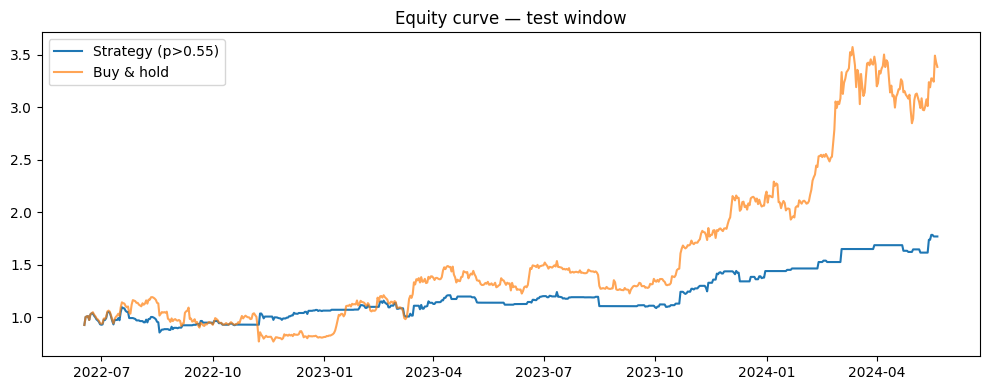

In [ ]:
ret_next = y_final_test.values
pos   = (p_dir > 0.55).astype(int)
strat = pos * ret_next
eq    = np.exp(np.cumsum(strat))
bh    = np.exp(np.cumsum(ret_next))
sharpe = strat.mean() / (strat.std() + 1e-12) * np.sqrt(365)
maxdd  = (eq / np.maximum.accumulate(eq) - 1).min()
win    = (ret_next[pos == 1] > 0).mean() if pos.sum() else float('nan')

print(f'Days in market : {pos.mean()*100:.0f}%   ({int(pos.sum())} of {len(pos)})')
print(f'Strategy return: {eq[-1]-1:+.2%}     Buy & hold: {bh[-1]-1:+.2%}')
print(f'Sharpe (ann.)  : {sharpe:.2f}')
print(f'Win rate       : {win:.2%}')
print(f'Max drawdown   : {maxdd:.2%}')

plt.figure(figsize=(10, 4))
plt.plot(y_final_test.index, eq, label='Strategy (p>0.55)')
plt.plot(y_final_test.index, bh, label='Buy & hold', alpha=.7)
plt.legend()
plt.title('Equity curve — test window')
plt.tight_layout()
plt.show()

Direction at a 7-Day Horizon

In [ ]:
temp_df = df.copy()

temp_df['target_7d'] = (temp_df['Close'].shift(-7) > temp_df['Close']).astype(int)

temp_df = temp_df.iloc[:-7]
df_7d_exp = temp_df[final_features + ['target_7d']].dropna()

split_idx_7d = int(len(df_7d_exp) * 0.80)

X_train_7d = df_7d_exp.iloc[:split_idx_7d][final_features]
y_train_7d = df_7d_exp.iloc[:split_idx_7d]['target_7d']
X_test_7d = df_7d_exp.iloc[split_idx_7d:][final_features]
y_test_7d = df_7d_exp.iloc[split_idx_7d:]['target_7d']

sc_7d = StandardScaler()
X_tr_sc_7d = pd.DataFrame(sc_7d.fit_transform(X_train_7d), columns=final_features, index=X_train_7d.index)
X_te_sc_7d = pd.DataFrame(sc_7d.transform(X_test_7d), columns=final_features, index=X_test_7d.index)

clf7 = XGBClassifier(n_estimators=400, learning_rate=0.02, max_depth=4, subsample=0.8,
                     colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)
clf7.fit(X_tr_sc_7d, y_train_7d)

p7 = clf7.predict_proba(X_te_sc_7d)[:, 1]
pred7 = (p7 > 0.5).astype(int)

print(f'\n7-day direction   Acc={accuracy_score(y_test_7d, pred7):.3f}  F1={f1_score(y_test_7d, pred7):.3f}  ROC-AUC={roc_auc_score(y_test_7d, p7):.3f}')


7-day direction   Acc=0.503  F1=0.515  ROC-AUC=0.520


Bull / Bear Regime Models

In [ ]:
data_regime = df.copy()
data_regime['y'] = (data_regime[TARGET] > 0).astype(int)
if 'bull' not in data_regime.columns:
    data_regime['bull'] = (data_regime['Close'] > data_regime['Close'].rolling(200).mean()).astype(int)

data_regime = data_regime.replace([np.inf, -np.inf], np.nan).dropna()
data_regime = data_regime[final_features + [TARGET, 'bull']].dropna()
data_regime['y'] = (data_regime[TARGET] > 0).astype(int)

for name, val in [('BULL (Close>MA200)', 1), ('BEAR (Close<=MA200)', 0)]:
    sub = data_regime[data_regime['bull'] == val]

    rtr = sub[sub.index.isin(X_final_train.index)]
    rte = sub[sub.index.isin(X_final_test.index)]

    if len(rte) < 20 or rte['y'].nunique() < 2:
        print(f'{name:22s} not enough test data in this regime')
        continue

    m  = XGBClassifier(**XGB_PARAMS).fit(rtr[final_features], rtr['y'])
    pp = m.predict_proba(rte[final_features])[:, 1]

    print(f'{name:22s} n={len(rte):4d}  Acc={accuracy_score(rte["y"],(pp>.5).astype(int)):.3f}  ROC-AUC={roc_auc_score(rte["y"],pp):.3f}')

BULL (Close>MA200)     n= 436  Acc=0.507  ROC-AUC=0.509
BEAR (Close<=MA200)    n= 269  Acc=0.494  ROC-AUC=0.491


Explainability (SHAP)

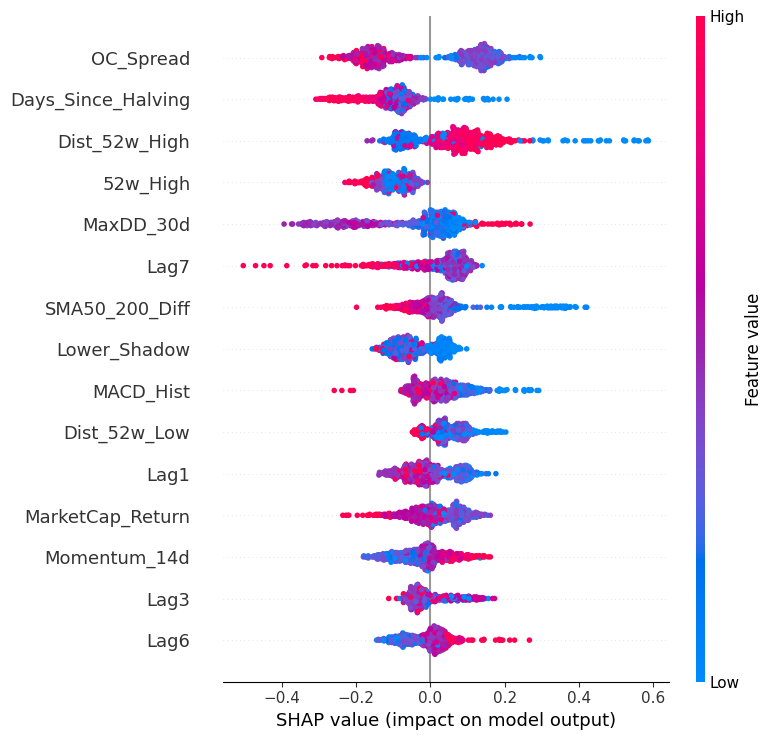

In [ ]:
try:
    try:
        import shap
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
        import shap

    expl = shap.TreeExplainer(clf)
    X_shap = pd.DataFrame(X_final_te_sc, columns=final_features)
    sv = expl.shap_values(X_shap)
    shap.summary_plot(sv, X_shap, max_display=15, show=True)
except Exception as e:
    print('SHAP skipped:', type(e).__name__, str(e)[:80])

Robustness Check: Forecast Horizon Analysis

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("EXPERIMENT: MULTI-HORIZON RETURN PREDICTION (1, 7, 30 Days)")

horizons = [1, 7, 30]
rows = []

for h in horizons:
    d_temp = df.copy()

    d_temp['y'] = np.log(d_temp['Close'].shift(-h) / d_temp['Close'])
    d = d_temp[final_features + ['y']].replace([np.inf, -np.inf], np.nan).dropna()
    split_idx = int(len(d) * 0.80)

    tr = d.iloc[:split_idx]
    te = d.iloc[split_idx:]

    Xtr = tr[final_features]
    ytr = tr['y']

    Xte = te[final_features]
    yte = te['y']
    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(Xtr, ytr)

    pred = rf.predict(Xte)

    rows.append([
        h,
        np.sqrt(mean_squared_error(yte, pred)),
        mean_absolute_error(yte, pred),
        r2_score(yte, pred),
        (np.sign(pred) == np.sign(yte)).mean()
    ])

rolling_results = pd.DataFrame(
    rows,
    columns=['Horizon', 'RMSE', 'MAE', 'R2', 'Directional_Accuracy']
)

print(rolling_results.to_string(index=False))

best = rolling_results.loc[rolling_results['Directional_Accuracy'].idxmax()]

print(
    f"\nHighest directional accuracy was observed "
    f"at the {int(best['Horizon'])}-day horizon "
    f"({best['Directional_Accuracy']:.2%})."
)

EXPERIMENT: MULTI-HORIZON RETURN PREDICTION (1, 7, 30 Days)
 Horizon     RMSE      MAE        R2  Directional_Accuracy
       1 0.031789 0.022191 -0.408829              0.492199
       7 0.116035 0.084039 -1.602175              0.498580
      30 0.304471 0.230571 -2.763278              0.505007

Highest directional accuracy was observed at the 30-day horizon (50.50%).


Results

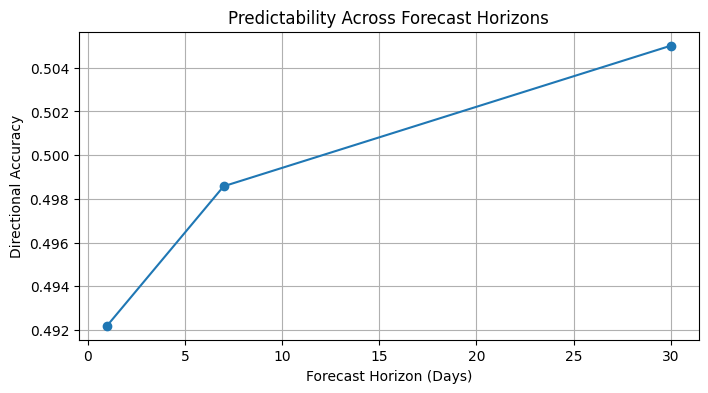

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(
    rolling_results['Horizon'],
    rolling_results['Directional_Accuracy'],
    marker='o'
)

plt.xlabel('Forecast Horizon (Days)')
plt.ylabel('Directional Accuracy')

plt.title(
    'Predictability Across Forecast Horizons'
)

plt.grid(True)

plt.show()

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100

    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")
    print(f"Directional Accuracy: {dir_acc:.2f}%")

model_catboost = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0

)
model_catboost.fit(X_final_tr_sc, y_final_train)
preds_catboost = model_catboost.predict(X_final_te_sc)
evaluate_model('CatBoost', y_final_test, preds_catboost)

Mean Absolute Error (MAE): 0.0211
Mean Squared Error (MSE): 0.0009
Root Mean Squared Error (RMSE): 0.0294
R-squared (R2): -0.2010
Directional Accuracy: 47.80%


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100

    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")
    print(f"Directional Accuracy: {dir_acc:.2f}%")

model_hist = HistGradientBoostingRegressor(
    max_iter=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

model_hist.fit(X_final_tr_sc, y_final_train)

preds_hist = model_hist.predict(X_final_te_sc)

evaluate_model('HistGradientBoosting', y_final_test, preds_hist)

Mean Absolute Error (MAE): 0.0226
Mean Squared Error (MSE): 0.0010
Root Mean Squared Error (RMSE): 0.0309
R-squared (R2): -0.3307
Directional Accuracy: 49.08%


In [ ]:
from sklearn.neural_network import MLPRegressor



model_mlp = MLPRegressor(

    hidden_layer_sizes=(32, 16),

    activation='relu',

    solver='adam',

    alpha=0.1,

    early_stopping=True,

    max_iter=500,

    random_state=42

)
model_mlp.fit(X_final_tr_sc, y_final_train)
preds_mlp = model_mlp.predict(X_final_te_sc)

evaluate_model('MLP_Regressor', y_final_test, preds_mlp)

Mean Absolute Error (MAE): 0.0198
Mean Squared Error (MSE): 0.0008
Root Mean Squared Error (RMSE): 0.0279
R-squared (R2): -0.0810
Directional Accuracy: 49.36%
